In [1]:
import json
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from extracao_comum import criar_cliente, extrair_vaga

load_dotenv("../.env")

PROCESSED_DIR = Path("../data/processed")
VALIDATION_DIR = Path("../data/validation")
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

vagas = pd.read_parquet(PROCESSED_DIR / "vagas_extraidas.parquet")

AZUL = "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.titlecolor": "#0b0b0b",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "ytick.labelcolor": "#52514e",
    "figure.dpi": 110,
})

print(f"{len(vagas)} vagas extraídas carregadas")

283 vagas extraídas carregadas


In [2]:
MODELO_PRINCIPAL = "openai/gpt-oss-120b"
MODELOS_VALIDACAO = [
    "deepseek/deepseek-v4-flash",
    "google/gemma-4-31b-it",
]
MODELOS = [MODELO_PRINCIPAL] + MODELOS_VALIDACAO

cliente = criar_cliente()

for modelo in MODELOS_VALIDACAO:
    print(f"=== {modelo} ===")
    print(extrair_vaga(cliente, modelo, vagas.iloc[0]["descricao"]), "\n")

=== deepseek/deepseek-v4-flash ===


skills_tecnicas=[] praticas_genai=['llm', 'ai agents', 'copilot'] ferramentas_ia_codigo=[] usa_ia_no_desenvolvimento='exige' senioridade='nao_informado' modalidade='nao_informado' exige_ingles=False exige_formacao_superior=False 

=== google/gemma-4-31b-it ===


skills_tecnicas=['api'] praticas_genai=['llm', 'ai agents', 'copilots', 'automation'] ferramentas_ia_codigo=[] usa_ia_no_desenvolvimento='exige' senioridade='nao_informado' modalidade='nao_informado' exige_ingles=False exige_formacao_superior=False 



In [3]:
from tqdm.auto import tqdm

db = sqlite3.connect(PROCESSED_DIR / "extracao.sqlite")

falhas = []
for modelo in MODELOS_VALIDACAO:
    feitas = {url for (url,) in db.execute(
        "SELECT url_base FROM extracoes WHERE modelo = ?", (modelo,))}
    pendentes = vagas[~vagas["url_base"].isin(feitas)]
    for _, vaga in tqdm(pendentes.iterrows(), total=len(pendentes), desc=modelo):
        try:
            extracao = extrair_vaga(cliente, modelo, vaga["descricao"])
        except Exception as erro:
            falhas.append((modelo, vaga["url_base"], repr(erro)[:120]))
            continue
        db.execute(
            "INSERT INTO extracoes (url_base, modelo, json) VALUES (?, ?, ?)",
            (vaga["url_base"], modelo, extracao.model_dump_json()),
        )
        db.commit()

if falhas:
    print(f"{len(falhas)} extrações falharam (essas vagas ficam fora da comparação):")
    for modelo, url, erro in falhas:
        print(f"  {modelo} · {url}\n    {erro}")

pd.read_sql("SELECT modelo, COUNT(*) AS vagas FROM extracoes GROUP BY modelo", db)

deepseek/deepseek-v4-flash: 0it [00:00, ?it/s]

google/gemma-4-31b-it: 0it [00:00, ?it/s]

,modelo,vagas
0,deepseek/deepseek-v4-flash,283
1,google/gemma-4-31b-it,283
2,openai/gpt-oss-120b,283


In [4]:
extracoes = pd.read_sql("SELECT url_base, modelo, json FROM extracoes", db)
extracoes = extracoes[extracoes["modelo"].isin(MODELOS)].reset_index(drop=True)
campos = pd.json_normalize(extracoes["json"].map(json.loads))
extracoes = pd.concat([extracoes[["url_base", "modelo"]], campos], axis=1)

cobertura = extracoes.groupby("url_base")["modelo"].nunique()
completas = sorted(cobertura[cobertura == len(MODELOS)].index)
extracoes = extracoes[extracoes["url_base"].isin(completas)]
print(f"{len(completas)} vagas com extração dos {len(MODELOS)} modelos")

CAMPOS_LISTA = ["skills_tecnicas", "praticas_genai", "ferramentas_ia_codigo"]
CAMPOS_CATEGORICOS = [
    "usa_ia_no_desenvolvimento", "senioridade", "modalidade",
    "exige_ingles", "exige_formacao_superior",
]

por_modelo = {
    modelo: grupo.set_index("url_base").loc[completas]
    for modelo, grupo in extracoes.groupby("modelo")
}

283 vagas com extração dos 3 modelos


In [5]:
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

linhas = []
for campo in CAMPOS_CATEGORICOS:
    tabela = extracoes.pivot(index="url_base", columns="modelo", values=campo).astype(str)
    dados, _ = aggregate_raters(tabela.to_numpy())
    linhas.append({
        "campo": campo,
        "unanimidade": tabela.nunique(axis=1).eq(1).mean(),
        "fleiss_kappa": fleiss_kappa(dados),
    })

categoricos = pd.DataFrame(linhas).set_index("campo")
categoricos.round(3)

,unanimidade,fleiss_kappa
campo,,
usa_ia_no_desenvolvimento,0.806,0.528
senioridade,0.788,0.658
modalidade,0.837,0.831
exige_ingles,0.880,0.829
exige_formacao_superior,0.915,0.878


In [6]:
def prf(extraida, referencia):
    extraida, referencia = set(extraida), set(referencia)
    if not extraida and not referencia:
        return 1.0, 1.0, 1.0
    inter = len(extraida & referencia)
    precisao = inter / len(extraida) if extraida else 0.0
    recall = inter / len(referencia) if referencia else 0.0
    f1 = 2 * precisao * recall / (precisao + recall) if precisao + recall else 0.0
    return precisao, recall, f1

linhas = []
for campo in CAMPOS_LISTA:
    for validador in MODELOS_VALIDACAO:
        medidas = [
            prf(p, v) for p, v in
            zip(por_modelo[MODELO_PRINCIPAL][campo], por_modelo[validador][campo])
        ]
        precisao, recall, f1 = (sum(m[i] for m in medidas) / len(medidas) for i in range(3))
        linhas.append({"campo": campo, "validador": validador.split("/")[-1],
                       "precisao": precisao, "recall": recall, "f1": f1})

listas = pd.DataFrame(linhas).set_index(["campo", "validador"])
listas.round(3)

precisao  recall     f1
campo                 validador                                 
skills_tecnicas       deepseek-v4-flash     0.634   0.734  0.656
                      gemma-4-31b-it        0.640   0.800  0.689
praticas_genai        deepseek-v4-flash     0.790   0.707  0.721
                      gemma-4-31b-it        0.800   0.743  0.745
ferramentas_ia_codigo deepseek-v4-flash     0.669   0.667  0.664
                      gemma-4-31b-it        0.678   0.688  0.677

In [7]:
from collections import Counter

principal = por_modelo[MODELO_PRINCIPAL]["skills_tecnicas"]
val_a = por_modelo[MODELOS_VALIDACAO[0]]["skills_tecnicas"]
val_b = por_modelo[MODELOS_VALIDACAO[1]]["skills_tecnicas"]

invencao, omissao = Counter(), Counter()
for p, a, b in zip(principal, val_a, val_b):
    p, a, b = set(p), set(a), set(b)
    invencao.update(p - a - b)
    omissao.update((a & b) - p)

print("Skills do principal não confirmadas por nenhum validador:")
print(pd.Series(invencao).sort_values(ascending=False).head(15).to_string())
print("\nSkills vistas pelos dois validadores e omitidas pelo principal:")
print(pd.Series(omissao).sort_values(ascending=False).head(15).to_string())

Skills do principal não confirmadas por nenhum validador:
vector database        21
prompt engineering     21
data pipelines         18
data preprocessing     15
cloud                  15
feature engineering    13
huggingface            13
observability          12
model monitoring       11
llm                    11
agile                  11
monitoring             10
model deployment       10
api development        10
rag                    10

Skills vistas pelos dois validadores e omitidas pelo principal:
api                 23
machine learning    14
hugging face        13
langgraph           12
vector databases    11
langchain           11
crewai               9
nlp                  9
node.js              7
mlops                5
llamaindex           5
aws                  3
autogen              3
python               3
gemini               3


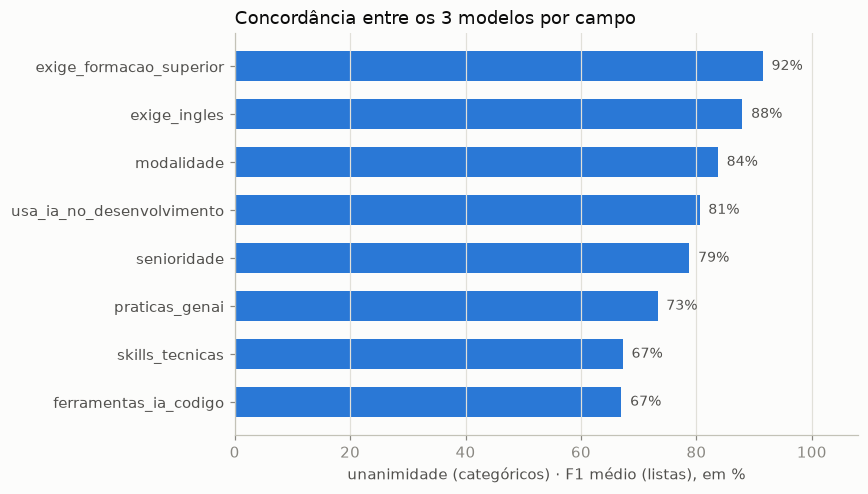

In [8]:
resumo = pd.concat([
    categoricos["unanimidade"],
    listas.groupby("campo")["f1"].mean(),
]).sort_values()

fig, ax = plt.subplots(figsize=(8, 0.45 * len(resumo) + 1))
ax.barh(resumo.index, resumo * 100, color=AZUL, height=0.62)
for i, v in enumerate(resumo):
    ax.text(v * 100 + 1.5, i, f"{v:.0%}", va="center", color="#52514e", fontsize=9)
ax.set_title("Concordância entre os 3 modelos por campo")
ax.set_xlabel("unanimidade (categóricos) · F1 médio (listas), em %")
ax.set_xlim(0, 108)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

In [9]:
ARQUIVO_ARBITRAGEM = VALIDATION_DIR / "divergencias_arbitragem.xlsx"

registros = []
for campo in CAMPOS_CATEGORICOS:
    tabela = extracoes.pivot(index="url_base", columns="modelo", values=campo).astype(str)
    for url, linha in tabela[tabela.nunique(axis=1) > 1].iterrows():
        registros.append({"url_base": url, "campo": campo,
                          **{m: linha[m] for m in MODELOS}})

f1_minimo = pd.Series(
    [min(prf(p, a)[2], prf(p, b)[2]) for p, a, b in zip(principal, val_a, val_b)],
    index=principal.index,
)
for url in f1_minimo[f1_minimo < 0.4].index:
    registros.append({
        "url_base": url, "campo": "skills_tecnicas",
        **{m: "; ".join(por_modelo[m].loc[url, "skills_tecnicas"]) for m in MODELOS},
    })

meta = vagas.set_index("url_base")[["job_title", "company", "descricao"]]
divergencias = pd.DataFrame(registros).join(meta, on="url_base")
divergencias["valor_correto"] = None

if ARQUIVO_ARBITRAGEM.exists():
    print(f"{ARQUIVO_ARBITRAGEM} já existe — mantido para não sobrescrever anotações.")
else:
    divergencias.to_excel(ARQUIVO_ARBITRAGEM, index=False)
    print(f"{len(divergencias)} divergências exportadas para {ARQUIVO_ARBITRAGEM}")
print(divergencias["campo"].value_counts().to_string())

..\data\validation\divergencias_arbitragem.xlsx já existe — mantido para não sobrescrever anotações.
campo
senioridade                  60
usa_ia_no_desenvolvimento    55
skills_tecnicas              47
modalidade                   46
exige_ingles                 34
exige_formacao_superior      24


In [10]:
BOOLEANOS = {"exige_ingles", "exige_formacao_superior"}
validadas = vagas.set_index("url_base")

if ARQUIVO_ARBITRAGEM.exists():
    arbitradas = pd.read_excel(ARQUIVO_ARBITRAGEM)
    anotadas = arbitradas.dropna(subset=["valor_correto"])
    print(f"{len(anotadas)} de {len(arbitradas)} divergências arbitradas")

    for _, linha in anotadas.iterrows():
        valor = str(linha["valor_correto"]).strip()
        if linha["campo"] in BOOLEANOS:
            valor = valor.lower() in ("true", "1", "sim", "verdadeiro")
        elif linha["campo"] == "skills_tecnicas":
            valor = [s.strip().lower() for s in valor.split(";") if s.strip()]
        validadas.at[linha["url_base"], linha["campo"]] = valor

    categoricas = anotadas[anotadas["campo"].isin(CAMPOS_CATEGORICOS)]
    if len(categoricas):
        acerto = (
            categoricas["valor_correto"].astype(str).str.strip().str.lower()
            == categoricas[MODELO_PRINCIPAL].astype(str).str.strip().str.lower()
        )
        print(f"principal acertou {acerto.mean():.0%} das divergências categóricas arbitradas")

validadas = validadas.reset_index()
validadas.to_parquet(PROCESSED_DIR / "vagas_validadas.parquet", index=False)
print(f"{len(validadas)} vagas salvas em vagas_validadas.parquet")

266 de 266 divergências arbitradas
principal acertou 57% das divergências categóricas arbitradas
283 vagas salvas em vagas_validadas.parquet


In [11]:
from sqlalchemy import create_engine

engine = create_engine(os.environ["NEON_DATABASE_URL"])

escalares = validadas.drop(columns=CAMPOS_LISTA)
escalares["search_keywords"] = escalares["search_keywords"].map("; ".join)
skills_long = pd.concat([
    validadas[["url_base", campo]].explode(campo).dropna()
        .rename(columns={campo: "item"}).assign(tipo=campo)
    for campo in CAMPOS_LISTA
])[["url_base", "tipo", "item"]]

escalares.to_sql("vagas", engine, if_exists="replace", index=False)
skills_long.to_sql("vagas_skills", engine, if_exists="replace", index=False)
print(f"publicado no Neon: vagas ({len(escalares)} linhas) e vagas_skills ({len(skills_long)} linhas)")

publicado no Neon: vagas (283 linhas) e vagas_skills (5096 linhas)
